# TP - MVA 2024 - AI for IQA

Name: Eliott Vigier
The objective of this TP is to work on the design of annotation campaigns, en essential part to build IQA datasets.

Answer the questions below and then export the notebook with the answers using the menu option File->Download .ipynb. **[Then submit your solution here (add your name to the filename)!](https://docs.google.com/forms/d/e/1FAIpQLScZqOU9T5Fuy021Z5-RXmmXFddjrnEyYX0gLsnPJ3EtV4akkg/viewform?usp=sharing)**

# Part 1 - Designing annotation campaigns to build IQA datasets

> ### Question1: Cite five difficulties encountered when developping an IQA dataset

> #### A1:

1) Size and diversity of the dataset
>
2) Subjective vision of quality images
>
3) Images with different distorsions (noise, blurring...)
>
4) Annotation is time consumming
>
5) Data privacy

> ### Question2: Cite four annotation methods for image quality

> #### A2:
<!-- 1. Pairwise with same content
2. Pairwise with different content
3. Ranking same content
4. Ranking with different content
5. Score assignment with same content -->
1) Pairwise comparison methods (PWC)
>
2) Score assignment (such as MOS)
>
3) Ranking same / with different content
>
4) Objectionnable difference

> ### Question3: For the two most common methods, which one do you think is a better choice? Cite a situation for each method where it is preferable. Answer these questions by citing two pros and two cons of each method and argument your choice of situations.


> #### A3:
Pairwise Comparison is a better choice for situations where the focus is on fine-grained quality differences between images with the same content. Score Assignment is preferable when evaluating diverse images with different content for overall quality.

> ### Q4: Let's now focus on Pairwise comparison methods (PWC) and Mean Opinion Score (MOS). Let's imagine that comparing the quality between two images can take on average 5 seconds (PWC), while evaluating the quality of a single image can take around 15 seconds (MOS). Calculate the necessary time to do a full pass of annotations for one person. What's the total number of data points (comparisons for PWC and evaluations for MOS) for both methods?


> #### A4:

For the Pairwise Comparison (PWC) method, each image needs to be compared with every other image.  
In total, there are $\frac{n(n-1)}{2}$ comparisons.  
Since each comparison takes 5 seconds, the total required time is:  
$
5 \cdot \frac{n(n-1)}{2} \ \text{seconds}.
$

For the Mean Opinion Score (MOS) method, only one evaluation is required per image.  
The total required time is:  
$
n \cdot 15 \ \text{seconds}.
$

#### Example: \(n = 50\)
- **PWC**:  

$
\text{Total comparisons} = \frac{50(50-1)}{2} = \frac{50 \cdot 49}{2} = 1225.
$

$
\text{Total time (PWC)} = 5 \cdot 1225 = 6125 \ \text{seconds}.
$

Convert to hours and minutes:  
$
6125 \ \text{seconds} = \frac{6125}{3600} \ \text{hours} = 1 \ \text{hour and} \ 42 \ \text{minutes}.
$

- **MOS**:  

$
\text{Total evaluations} = 50.
$

$
\text{Total time (MOS)} = 50 \cdot 15 = 750 \ \text{seconds}.
$

Convert to hours and minutes:  
$
750 \ \text{seconds} = \frac{750}{3600} \ \text{hours} = 0 \ \text{hours and} \ 12 \ \text{minutes}.
$

Results for \(n = 50\):
- **PWC**: 1225 comparisons, 6125 seconds $(1 \ \text{hour and} \ 42 \ \text{minutes})$.  
- **MOS**: 50 evaluations, 750 seconds $(0 \ \text{hours and} \ 12 \ \text{minutes})$.


> ### Q5: Given an annotation campaign with N images. How does the time spent on the full annotation campaign change for each method? Plot the evolution of the total annotation cost per person (in minutes) in terms of N (1 to 50) for both methods. What is the minimum number of images on which comparisons (PWC) is more costly?


In [35]:
import numpy as np
import matplotlib.pyplot as plt

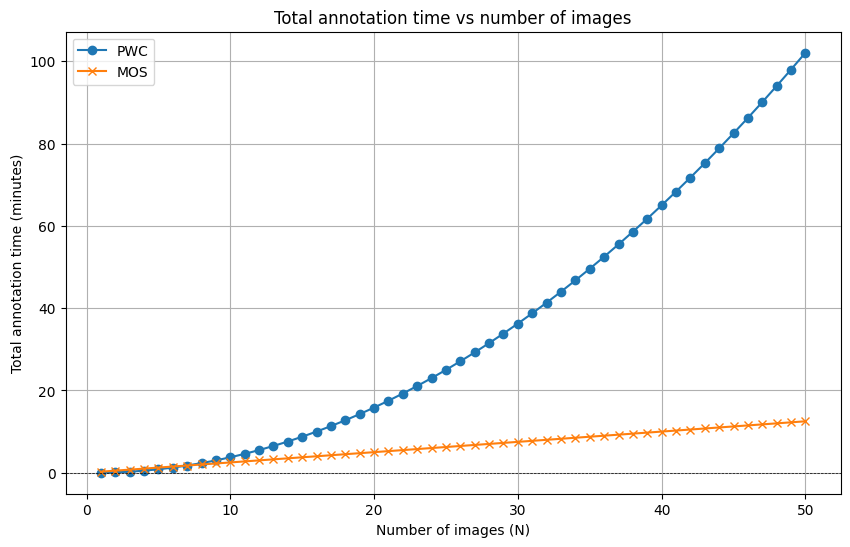

The minimum number of images where PWC is more costly than MOS is: 8


In [36]:
N = np.arange(1, 51)
time_per_comparison = 5
time_per_mos = 15

# Time
time_pwc = 5 * (N * (N - 1)) / 2
time_mos = 15 * N

time_pwc_minutes = time_pwc/60
time_mos_minutes = time_mos/60

# Plots
plt.figure(figsize=(10, 6))
plt.plot(N, time_pwc_minutes, label="PWC", marker='o')
plt.plot(N, time_mos_minutes, label="MOS", marker='x')
plt.xlabel("Number of images (N)")
plt.ylabel("Total annotation time (minutes)")
plt.title("Total annotation time vs number of images")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# Calculate the minimum number of images where PWC is more costly than MOS
min_costly_images = np.min(N[time_pwc > time_mos]) if np.any(time_pwc > time_mos) else None
print(f"The minimum number of images where PWC is more costly than MOS is: {min_costly_images}")

The minimum number of images where PWC is more costly than MOS is: 8.

#### A5:

> ### Q6: Redo the plot of Q5 taking into consideration that we need five times more single annotations to reach a similar precision with the comparisons

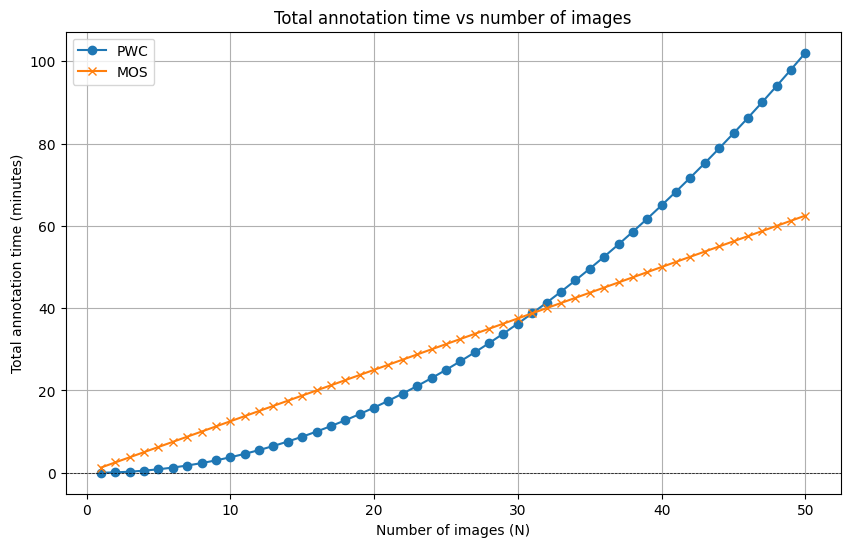

The minimum number of images where PWC is more costly than MOS is: 32


In [37]:
N = np.arange(1, 51)
time_per_comparison = 5
time_per_mos = 15

# Time
time_pwc = 5 * (N * (N - 1)) / 2
time_mos = 15 * N * 5

time_pwc_minutes = time_pwc/60
time_mos_minutes = time_mos/60

# Plots
plt.figure(figsize=(10, 6))
plt.plot(N, time_pwc_minutes, label="PWC", marker='o')
plt.plot(N, time_mos_minutes, label="MOS", marker='x')
plt.xlabel("Number of images (N)")
plt.ylabel("Total annotation time (minutes)")
plt.title("Total annotation time vs number of images")
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# Calculate the minimum number of images where PWC is more costly than MOS
min_costly_images = np.min(N[time_pwc > time_mos]) if np.any(time_pwc > time_mos) else None
print(f"The minimum number of images where PWC is more costly than MOS is: {min_costly_images}")

The minimum number of images where PWC is more costly than MOS is: 32.

#### A6

> ### Q7: For big data sets, it is not feasible to do a complete design for all annotators and all images. How can we reduce the number of comparisons without losing much precision?

> #### A7:


> When the data is large, it is not possible to achieve a complete design (a full passage on all data points for each observer), hence a sampling strategy is necessary. To make big annotation campaigns more efficient, we can resort to active sampling techniques. Active sampling [1,2,3,4,5] is the process of optimally choosing the image pairs for PWC annotation tasks. Some of these techniques are more sophisticated than others.
>   ###### [1] Chen, Bennett, Collins-Thompson, Horvitz (2013). Pairwise ranking aggregation in a crowdsourced setting. In Proceedings of the sixth ACM international conference on Web search and data mining, pp. 193–202
>   ###### [2] Ye, Doermann (2014). Active sampling for subjective image quality assessment. In Proceedings of the IEEE conference on computer vision and pattern recognition, pp. 4249–4256.
>   ###### [3] Li, Mantiuk, Wang, Ling, Callet (2018). Hybrid-MST: A hybrid active sampling strategy for pairwise preference aggregation. arXiv preprint arXiv:1810.08851, pp.
>   ###### [4] Xu, Xiong, Chen, Huang, Yao (2018). Hodgerank with information maximization for crowdsourced pairwise ranking aggregation. In Proceedings of the AAAI Conference on Artificial Intelligence, pp.
>   ###### [5] Mikhailiuk, Wilmot, Perez-Ortiz, Yue, Mantiuk (2020). Active Sampling for Pairwise Comparisons via Approximate Message Passing and Information Gain Maximization. arXiv preprint arXiv:2004.05691, pp.
> ### Q8: What do you think are straighforward techniques of sampling in a pairwise comparison experiment (other than the ones mentioned above)? list two

> #### A8:

Random sampling : it involves selecting image pairs randomly from the dataset for comparison.
This method covers many pairs without needing prior data knowledge.

>

"Transitive method" : If image A has already been compared with B, and B with C, and the results indicate
A>B and
B>C, there is no need to compare A and C directly. This approach reduces redundant comparisons by leveraging the transitive property of rankings.

Systematic sampling: Selecting every n-th pair from a list, starting at a random point.

# Part 2 - PWC simulation experiment

In this part, we will be testing the previous assumptions by simulating a pairwise comparison experiment

In [38]:
import numpy as np
import time
import random
import math
from numpy.random import normal
import matplotlib.pyplot as plt
import torch
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error
from scipy.stats import truncnorm
plt.rcParams['figure.figsize'] = [12.0, 8.0]

!pip install networkx==2.8.5
import networkx as nx

nx.__version__

'2.8.5'

In [39]:
# The following lines install the necessary packages in the colab environment
try:
    from google.colab import files
    !pip install -q hdf5storage

    !rm -fr TP-IQA
    !git clone --single-branch --quiet https://github.com/DXOMARK-OCTO/TP-IQA
    !cp -r TP-IQA/* .

except ImportError:
    # %matplotlib notebook
    pass

%matplotlib inline

import activepwcanalysis as adaComp
from activepwcanalysis import predictNext

> ### Q9: List the essential steps to simulate a pairwise comparison experiment.

> #### A9:

We need to choose:

>
a sampling strategy (Random/Active sampling)
>
to organize and store annotations
>
to compute rankings or scores from the pairwise data

## A - Observer simulator model

> Scaling methods transform the comparison matrices in a pairwise comparison experiment into JOD scores (Image quality scores). These methods assume that the quality of an image, from an observer's point of view, follows a certain probability distribution. This is called an observer model and is still subject to research. We will follow the popular Thurstone case V (Thurstone, 1927) model [6]. This model supposes that the quality difference between two images follows a random Gaussian distribution, whose uncertainty reflects the inter and intra-annotator disagreement. This noise follows the rule that for two images $r_i, r_j$, if 75\% of the comparisons indicated that $r_i$ was of better quality than $r_j$ , $P(r_i > r_j) = 0.75$, then the difference is exactly 1 $JOD$ (a unit in our image quality scale). For this distance and probability, for a gaussian distribution with 0 mean, the standard deviation is $\sigma=1.4826$.
> ###### [6] A practical guide and software for analysing pairwise comparison experiments. arXiv preprint arXiv:1712.03686, pp

> ### Q10: Fill in the following function, called pwcObserverSimulator, that takes a pair of image scores (pairScores), the standard deviation (jodStd) and returns a simulated comparison based on the Thurstone case V observer model. The function should return the rank of the input images:
> ### - (0,1) if the second image is better or
> ### - (1,0) if the first element has better quality.
> ### The function should also return the score difference with the noise.

In [40]:
def pwcObserverSimulator(pairScores, jodStd=1.4826, **kwargs):
    """
     1 - Our simulator takes a pair of images with known quality scores (1,2,3,4,),
     2 - Adds an observer bias that follows N(0, jodStd)
     3 - Computes the difference and returns the rank and the score difference with the observer's bias
    """
    score1, score2 = pairScores

    noise = np.random.normal(0, jodStd)

    scorediff = (score1 - score2) + noise

    if scorediff > 0:

      rank = (1,0)

    else:

      rank = (0,1)

    return rank,scorediff

> ### A10:

> ### Q11: Fill in the following function, called mosObserverSimulator, that takes an image score, adds noise, and returns the estimated MOS score, rounded to a certain precision.

In [41]:
def mosObserverSimulator(imageScore, mosStd, **kwargs):
    """
     1 - Our simulator takes an image with a known quality score (1,2,3,4,),
     2 - Adds an observer bias that follows N(0, mosStd)
     3 - Computes and returns the new noisy score
    """
    noise = np.random.normal(0, mosStd)

    return round(imageScore + noise, 2)

> A11:

## B - Sampling algorithms


> To see the effectiveness of the active sampling, we will be comparing a popular algorithm, ASAP [5] to three other simple sampling approaches: random sampling, ranking based sampling, and an optimized ranking based sampling. Sometimes, sampling algorithms can be computionally heavy. To accelerate the sampling process, instead of generating one pair at a time, we generate a batch of pairs, where each image is present at least one time. In total, we have batches of size n-1.

> ### Q12: Fill in the first two of the following functions that implement the three sampling approaches mentioned above.

In [42]:
def randomSampling(**kwargs):
    """
    1 - Takes the number of images and generate a batch of n-1 pairs where all images are at least once (we should avoid comparing the pair with itself)
    2 - Return the list of pairs
    """
    nbImages = kwargs.get('nbImages', None)

    imageIndices = list(range(nbImages))
    random.shuffle(imageIndices)

    pairList = []

    for i in range(nbImages - 1):

      pairList.append((imageIndices[i], imageIndices[i + 1]))

    return pairList

def rankingBasedSampling(**kwargs):
    """
    1 - Takes the image scores and calculates the rank of each image.
    2 - Based on the ranking, select a batch of n-1 pairs, by taking the consecutive pairs of images.
    3 - Return the list of pairs
    """
    compMat = kwargs.get('imageScores', None)
    sortedIndices = np.argsort(compMat)

    pairList = []

    for i in range(len(sortedIndices) - 1):

      pairList.append((sortedIndices[i], sortedIndices[i + 1]))

    return pairList

def optRankingBasedSampling(**kwargs):
    """
    1 - Takes the image scores and calculates the rank of each image.
    2 - Based on the ranking, select a batch of n-1 pairs, by randomly sampling from the local neighbors around each image (25% of the total images).
    3 - Return the list of pairs
    """
    imageScores = kwargs.get('imageScores', None)

    neighborSize = math.ceil(0.05 * len(imageScores))

    if neighborSize <=1:
        return rankingBasedSampling(imageScores=imageScores)

    sortedIndices = np.argsort(imageScores)

    indicesSelected = []
    pairList = []

    while(len(indicesSelected) < len(imageScores)):
        selectedNode = random.sample([idx for idx in sortedIndices if idx not in indicesSelected], 1)[0]

        minBound = max(0, selectedNode - neighborSize//2)
        maxBound = min(len(imageScores), minBound + neighborSize +1)

        neighbourPool = [idx for idx in sortedIndices[minBound: maxBound] if idx!=selectedNode]
        pairSelected = (selectedNode, random.sample(neighbourPool,1)[0])
        pairList += [pairSelected]
        indicesSelected += [selectedNode]

    pairList.remove(next(p for p in pairList if next(q for q in indicesSelected if len([k for k in pairList if q in k]) > 2) in p ))
    return pairList

## C - Monte Carlo Simulation

> To simulate a PWC experiment, we need the following elements:
>   - The number of images
>   - The number of standard trials (1 st = number of full pass over the images)
>   - The observer simulation parameters
>   - The scaling algorithm
>   - The sampling algorithm
>   - The ground truth scores of the images
>   - The performance evaluation metrics

> ### Q13: Fill in the following function, called monteCarloPwcSim, that takes the list of image scores, the number of standard trials, the observer simulator and the sampling algorithm function, simulates a pairwise comparison experiment and returns the average image scores after each batch of pairs. Each batch of pairs is equal to n-1 pairs.

In [43]:
def monteCarloPwcSim(groundTruthScores, nbTrials, observerSimulator, samplingAlgorithm, **kwargs):
    """
    1 - Our simulator takes the list of groundtruth image scores, the number of standard trials, and the simulations functions
    2 - For each iteration, we compute the image scores
    3 - Then, we select the next batch of pairs where each batch consists for n-1 pairs, where n is the number of images. In this case, 1 st = n/2 * nb batches.
    4 - We simulate the comparisons and update the comparison matrix
    5 - Returns the average image scores per batch.
    """
    nbImages = len(groundTruthScores)
    nbSimulations = kwargs.get('nbSimulations', 1)

    # Total number of batches
    nbBatches = math.ceil(nbImages/2 * nbTrials)
    # Comparison matrix
    compMat = np.zeros((nbImages, nbImages))
    # Generate batch of image pairs
    compBatch = randomSampling(nbImages=nbImages)

    avgJodScoreEvolution = []
    avgStdScoreEvolution = []

    normalizedGroundTruthScores = adaComp.normalizeScale(groundTruthScores, shiftToRefImage=True)
    # Simulate comparisons
    for pair in compBatch:
        # Simulate observer, always first element is best
        pairScores = [groundTruthScores[pair[0]], groundTruthScores[pair[1]]]
        orderedPairIdx, _ = observerSimulator(pairScores)
        pair1Index = pair[orderedPairIdx[0]]
        pair2Index = pair[orderedPairIdx[1]]
        # Update comparison matrix: COMPLETE HERE, by defining pair1Index and pair2Index
        orderedPair = [pair1Index, pair2Index]
        compMat = adaComp.updateCompMat(orderedPair, compMat)
    # Score generation
    jodScores,jodStds = adaComp.JODScores(compMat)
    compBatch = samplingAlgorithm(nbImages=nbImages, imageScores=jodScores)


    # evolution (per Batch) of the simulated jod scores



    avgJodScoreEvolution.append(np.mean(jodScores))
    avgStdScoreEvolution.append(np.mean(jodStds))

    return avgJodScoreEvolution, avgStdScoreEvolution

> A13: Explain the code below

In [44]:
def monteCarloPwcSim(groundTruthScores, nbTrials, observerSimulator, samplingAlgorithm, **kwargs):
    """
    1 - Our simulator takes the list of groundtruth image scores, the number of standard trials, and the simulations functions
    2 - For each iteration, we compute the image scores
    3 - Then, we select the next batch of pairs where each batch consists for n-1 pairs, where n is the number of images. In this case, 1 st = n/2 * nb batches.
    4 - We simulate the comparisons and update the comparison matrix
    5 - Returns the average image scores per batch.
    """

    useCuda = torch.cuda.is_available()
    nbImages = len(groundTruthScores)
    nbSimulations = kwargs.get('nbSimulations', 1)

    # Total number of comparisons
    totalComparisons = nbImages * (nbImages - 1)/2 * nbTrials
    # Total number of batches
    nbBatches = math.ceil(nbImages/2 * nbTrials)

    simulatedJodScores = []
    simulatedStdScores = []
    time1 = time.time()

    for i in range(nbSimulations):
        # Intialize comparison matrix
        compMat = np.zeros((nbImages, nbImages))
        # Initiate batch of image pairs
        compBatch = randomSampling(nbImages=nbImages)
        jodScoresEvolution = []
        jodStdEvolution = []
        for batch in range(nbBatches-1):
            # Simulate comparisons
            for pair in compBatch:
                # Simulate observer, always first element is best
                pairScores = [groundTruthScores[pair[0]], groundTruthScores[pair[1]]]
                orderedPairIdx, _ = observerSimulator(pairScores)
                orderedPair = [pair[orderedPairIdx[0]], pair[orderedPairIdx[1]]]
                # Update comparison matrix
                compMat = adaComp.updateCompMat(orderedPair, compMat)

            # Score generation
            jodScores,jodStds = adaComp.JODScores(compMat)
            jodScoresEvolution += [jodScores]
            jodStdEvolution += [jodStds]
            compBatch = samplingAlgorithm(compMat=compMat, nbImages=nbImages, imageScores=jodScores, useCuda=useCuda)


        simulatedJodScores += [jodScoresEvolution]
        simulatedStdScores += [jodStdEvolution]

    # evolution (per Batch) of the simulated jod scores
    avgJodScoreEvolution = np.mean(simulatedJodScores, axis=0)
    avgStdScoreEvolution = np.mean(simulatedStdScores, axis=0)

    return avgJodScoreEvolution, avgStdScoreEvolution, (time.time()-time1)/nbSimulations

This code uses Monte Carlo simulations to mimic a pairwise comparison process based on ground truth scores. The main goal is to simulate annotation campaigns by modeling observers and using sampling algorithms to make the process more efficient. In each iteration, it selects a batch of image pairs to compare, updates a comparison matrix based on the simulated observations, and calculates Just Noticeable Difference (JOD) scores along with their standard deviations. By repeating this process multiple times, it tracks how the scores evolve across batches, explaining the effectiveness of the sampling algorithm and observer simulation.

> ### Q14: What are the two types of correlations that can be used to evaluate the performance of our simulation? What's the difference between them?

> #### A14:

1. Pearson Correlation
$
r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}
$

2. Spearman Rank Correlation
$
\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}
$


The Pearson correlation measures the strength of a linear relationship between two variables, while the Spearman rank correlation assesses the strength and direction of a monotonic relationship based on rank orders.

> ### Q15 - Finally, lets define a function that generates, the ground truth score of a set of images. Define a function with input jodRange and nbImages, and outputs a set of 'nbImages' elements o values from 0 to jodRange.

> A15


In [45]:
def generateGroundTruthScores(jodRange, nbImages):

  groundTruthScores = np.random.randint(0, jodRange+1, nbImages)

  return groundTruthScores

> ### Q16: Let's fix the number of images in the data set to 20 and their JOD range to 10. Using the previous code, plot the evolution of the SROCC, PLCC and STD as we augment the number of standard trials up to 3, for all the 4 algorithms. What conclusion can you extract?

In [46]:
nbImages = 20
jodRange = 10

groundTruthScores = generateGroundTruthScores(jodRange, nbImages)

In [47]:
def compute_metrics(estimated_scores, ground_truth_scores):

    plcc, _ = pearsonr(ground_truth_scores, estimated_scores)
    srocc, _ = spearmanr(ground_truth_scores, estimated_scores)
    std = np.std(estimated_scores)

    return plcc, srocc, std

In [48]:
algorithms = {
    "random": randomSampling,
    "ranking": rankingBasedSampling,
    "optRanking": optRankingBasedSampling
}

In [49]:
trial_range = [1, 2, 3]

results = {
    algo_name: {
        "nbTrials": [],
        "PLCC": [],
        "SROCC": [],
        "STD": []
    }
    for algo_name in algorithms
}

for algo_name, algo_func in algorithms.items():
    for nbTrials in trial_range:

        avgJodScoreEvolution, avgStdScoreEvolution, duration = monteCarloPwcSim(
            groundTruthScores=groundTruthScores,
            nbTrials=nbTrials,
            observerSimulator=pwcObserverSimulator,
            samplingAlgorithm=algo_func
        )

        finalJodScores = avgJodScoreEvolution[-1]

        plcc, srocc, std_err = compute_metrics(finalJodScores, groundTruthScores)

        results[algo_name]["nbTrials"].append(nbTrials)
        results[algo_name]["PLCC"].append(plcc)
        results[algo_name]["SROCC"].append(srocc)
        results[algo_name]["STD"].append(std_err)

        print(f"Algorithm={algo_name}, nbTrials={nbTrials}, PLCC={plcc:.3f}, SROCC={srocc:.3f}, STD={std_err:.3f}")

Algorithm=random, nbTrials=1, PLCC=-0.955, SROCC=-0.945, STD=1.483
Algorithm=random, nbTrials=2, PLCC=-0.994, SROCC=-0.994, STD=1.483
Algorithm=random, nbTrials=3, PLCC=-0.993, SROCC=-0.994, STD=1.483
Algorithm=ranking, nbTrials=1, PLCC=-0.954, SROCC=-0.985, STD=1.483
Algorithm=ranking, nbTrials=2, PLCC=-0.967, SROCC=-0.994, STD=1.483
Algorithm=ranking, nbTrials=3, PLCC=-0.970, SROCC=-0.992, STD=1.483
Algorithm=optRanking, nbTrials=1, PLCC=-0.971, SROCC=-0.983, STD=1.483
Algorithm=optRanking, nbTrials=2, PLCC=-0.948, SROCC=-0.990, STD=1.483
Algorithm=optRanking, nbTrials=3, PLCC=-0.949, SROCC=-0.994, STD=1.483


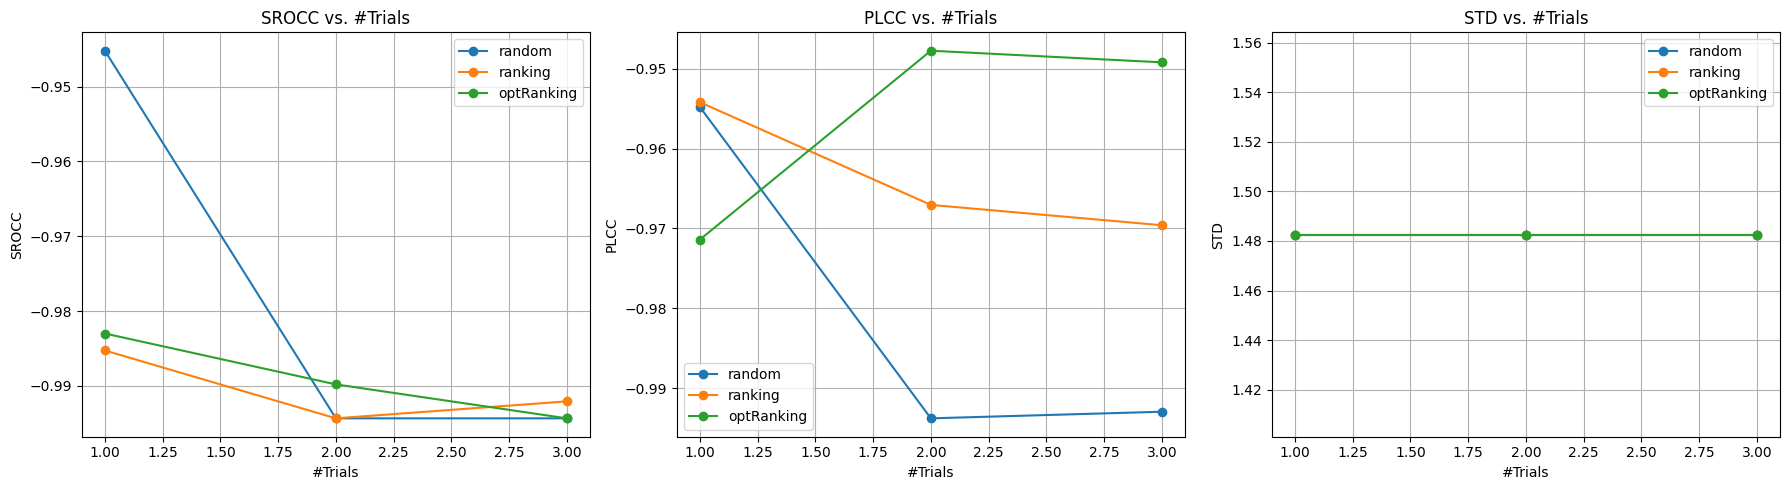

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# SROCC
for algo_name in results:
    axs[0].plot(results[algo_name]["nbTrials"],
                results[algo_name]["SROCC"],
                label=algo_name, marker='o')
axs[0].set_title("SROCC vs. #Trials")
axs[0].set_xlabel("#Trials")
axs[0].set_ylabel("SROCC")
axs[0].legend()
axs[0].grid(True)

# PLCC
for algo_name in results:
    axs[1].plot(results[algo_name]["nbTrials"],
                results[algo_name]["PLCC"],
                label=algo_name, marker='o')
axs[1].set_title("PLCC vs. #Trials")
axs[1].set_xlabel("#Trials")
axs[1].set_ylabel("PLCC")
axs[1].legend()
axs[1].grid(True)

# STD
for algo_name in results:
    axs[2].plot(results[algo_name]["nbTrials"],
                results[algo_name]["STD"],
                label=algo_name, marker='o')
axs[2].set_title("STD vs. #Trials")
axs[2].set_xlabel("#Trials")
axs[2].set_ylabel("STD")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


The results shown in the graphs appear inconsistent, as the SROCC and PLCC scores are close to -1, whereas they should be closer to +1 for a valid image comparison. Positive scores closer to 1 indicate a strong and direct relationship, which is expected in such metrics.

The results suggest that there is maybe an error in our function **pwcObserverSimulator** which seems to invert the ranks incorrectly. Therefor, we will modify it.

In [51]:
def pwcObserverSimulator(pairScores, jodStd=1.4826, **kwargs):
    """
     1 - Our simulator takes a pair of images with known quality scores (1,2,3,4,),
     2 - Adds an observer bias that follows N(0, jodStd)
     3 - Computes the difference and returns the rank and the score difference with the observer's bias
    """
    score1, score2 = pairScores

    noise = np.random.normal(0, jodStd)

    scorediff = (score1 - score2) + noise

    if scorediff > 0:
      rank = (0,1)
    else:
      rank = (1,0)

    return rank,scorediff

In [52]:
trial_range = [1, 2, 3]

results = {
    algo_name: {
        "nbTrials": [],
        "PLCC": [],
        "SROCC": [],
        "STD": []
    }
    for algo_name in algorithms
}

for algo_name, algo_func in algorithms.items():
  for nbTrials in trial_range:

    avgJodScoreEvolution, avgStdScoreEvolution, duration = monteCarloPwcSim(
        groundTruthScores=groundTruthScores,
        nbTrials=nbTrials,
        observerSimulator=pwcObserverSimulator,
        samplingAlgorithm=algo_func
    )

    finalJodScores = avgJodScoreEvolution[-1]

    plcc, srocc, std_err = compute_metrics(finalJodScores, groundTruthScores)

    results[algo_name]["nbTrials"].append(nbTrials)
    results[algo_name]["PLCC"].append(plcc)
    results[algo_name]["SROCC"].append(srocc)
    results[algo_name]["STD"].append(std_err)

    print(f"Algorithm={algo_name}, nbTrials={nbTrials}, PLCC={plcc:.3f}, SROCC={srocc:.3f}, STD={std_err:.3f}")

Algorithm=random, nbTrials=1, PLCC=0.979, SROCC=0.984, STD=1.483
Algorithm=random, nbTrials=2, PLCC=0.977, SROCC=0.966, STD=1.483
Algorithm=random, nbTrials=3, PLCC=0.996, SROCC=0.994, STD=1.483
Algorithm=ranking, nbTrials=1, PLCC=0.966, SROCC=0.987, STD=1.483
Algorithm=ranking, nbTrials=2, PLCC=0.985, SROCC=0.987, STD=1.483
Algorithm=ranking, nbTrials=3, PLCC=0.930, SROCC=0.992, STD=1.483
Algorithm=optRanking, nbTrials=1, PLCC=0.973, SROCC=0.994, STD=1.483
Algorithm=optRanking, nbTrials=2, PLCC=0.951, SROCC=0.986, STD=1.483
Algorithm=optRanking, nbTrials=3, PLCC=0.969, SROCC=0.994, STD=1.483


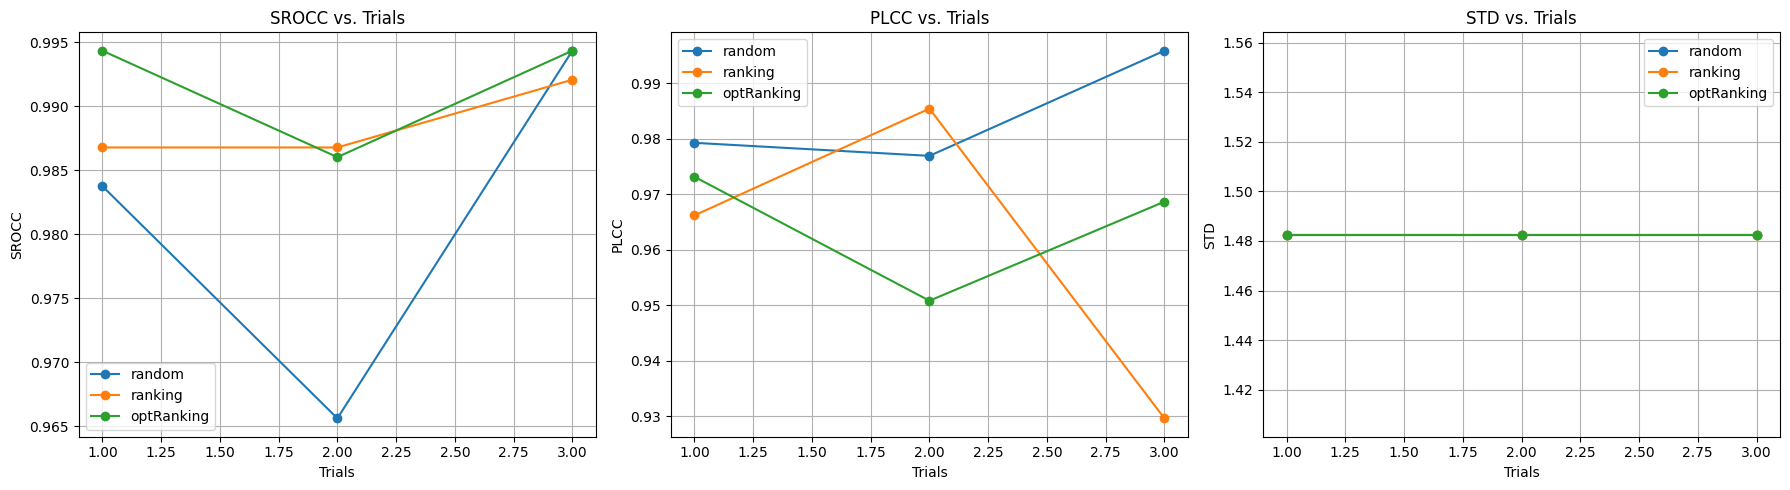

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# SROCC
for algo_name in results:
  axs[0].plot(results[algo_name]["nbTrials"],
              results[algo_name]["SROCC"],
              label=algo_name, marker='o')
axs[0].set_title("SROCC vs. Trials")
axs[0].set_xlabel("Trials")
axs[0].set_ylabel("SROCC")
axs[0].legend()
axs[0].grid(True)

# PLCC
for algo_name in results:
  axs[1].plot(results[algo_name]["nbTrials"],
              results[algo_name]["PLCC"],
              label=algo_name, marker='o')
axs[1].set_title("PLCC vs. Trials")
axs[1].set_xlabel("Trials")
axs[1].set_ylabel("PLCC")
axs[1].legend()
axs[1].grid(True)

# STD
for algo_name in results:
  axs[2].plot(results[algo_name]["nbTrials"],
              results[algo_name]["STD"],
              label=algo_name, marker='o')
axs[2].set_title("STD vs. Trials")
axs[2].set_xlabel("Trials")
axs[2].set_ylabel("STD")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

After correcting the issue in the function, the new results seems more correct.  The SROCC and PLCC values are now closer to 1, indicating a strong positive correlation.

The results look more reasonable, but there is still a lot of fluctuation, making it hard to draw clear conclusions. We would need to test over a wider range of trials to be more confident.

> A16:

> ### Q17: Let's now fix the number of standard trials (a.k.a the number of comparisons) to 1.5, and vary the JOD range of the scene. Plot again the SROCC, PLC and STD according to a varing JOD (2-20), for your 4 sampling algorithms. How do you interpret the results? Regarding the std, which sapling algorithm is better? why do you think this is the case?

For 1 simulation

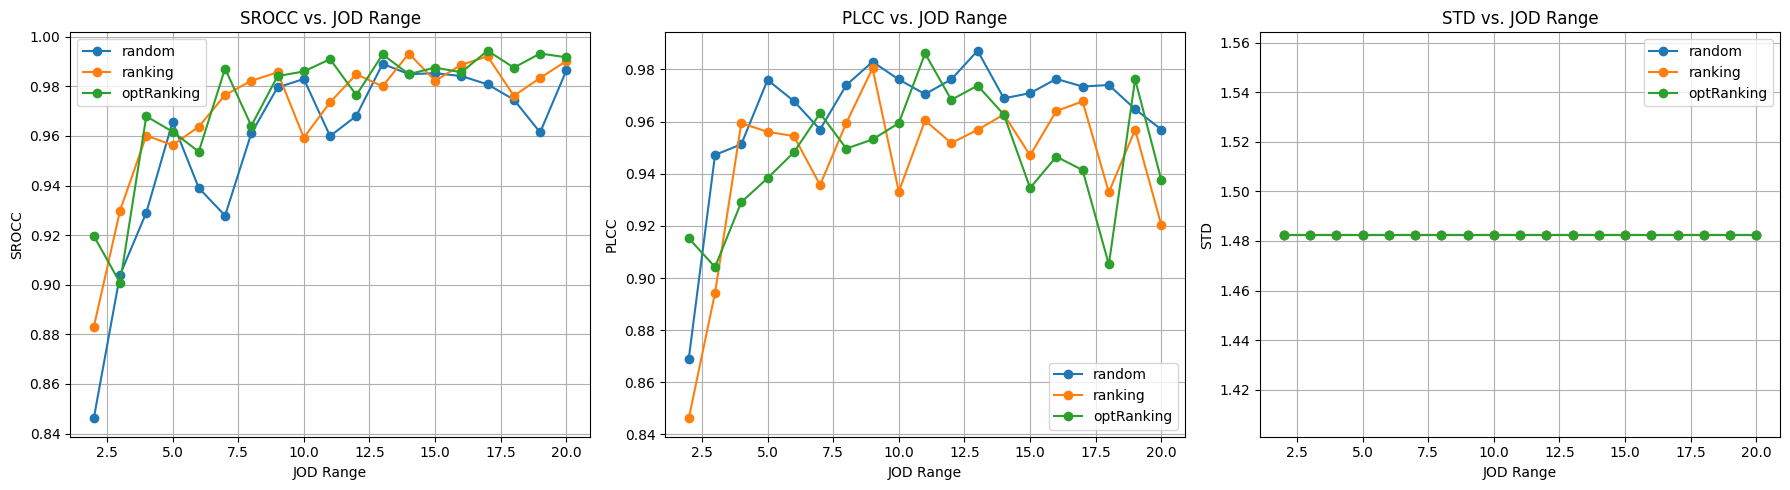

In [54]:
nbImages = 20
nbTrials = 1.5

algorithms = {
    "random": randomSampling,
    "ranking": rankingBasedSampling,
    "optRanking": optRankingBasedSampling,
}

jod_range_list = range(2,21)

results = {
    algo_name: {
        "jod_range": [],
        "PLCC": [],
        "SROCC": [],
        "STD": []
    }
    for algo_name in algorithms
}

for jodRange in jod_range_list:

  groundTruthScores = generateGroundTruthScores(jodRange, nbImages)

  for algo_name, algo_func in algorithms.items():

    avgJodScoreEvolution, avgStdScoreEvolution, duration = monteCarloPwcSim(
        groundTruthScores=groundTruthScores,
        nbTrials=nbTrials,
        observerSimulator=pwcObserverSimulator,
        samplingAlgorithm=algo_func
    )

    finalJodScores = avgJodScoreEvolution[-1]

    plcc, srocc, std_err = compute_metrics(finalJodScores, groundTruthScores)

    results[algo_name]["jod_range"].append(jodRange)
    results[algo_name]["PLCC"].append(plcc)
    results[algo_name]["SROCC"].append(srocc)
    results[algo_name]["STD"].append(std_err)

# Plot results
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# SROCC
for algo_name in results:
  axs[0].plot(results[algo_name]["jod_range"],
              results[algo_name]["SROCC"],
              label=algo_name, marker='o')
axs[0].set_title("SROCC vs. JOD Range")
axs[0].set_xlabel("JOD Range")
axs[0].set_ylabel("SROCC")
axs[0].legend()
axs[0].grid(True)

# PLCC
for algo_name in results:
  axs[1].plot(results[algo_name]["jod_range"],
              results[algo_name]["PLCC"],
              label=algo_name, marker='o')
axs[1].set_title("PLCC vs. JOD Range")
axs[1].set_xlabel("JOD Range")
axs[1].set_ylabel("PLCC")
axs[1].legend()
axs[1].grid(True)

# STD
for algo_name in results:
  axs[2].plot(results[algo_name]["jod_range"],
              results[algo_name]["STD"],
              label=algo_name, marker='o')
axs[2].set_title("STD vs. JOD Range")
axs[2].set_xlabel("JOD Range")
axs[2].set_ylabel("STD")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

For 5 simulations.

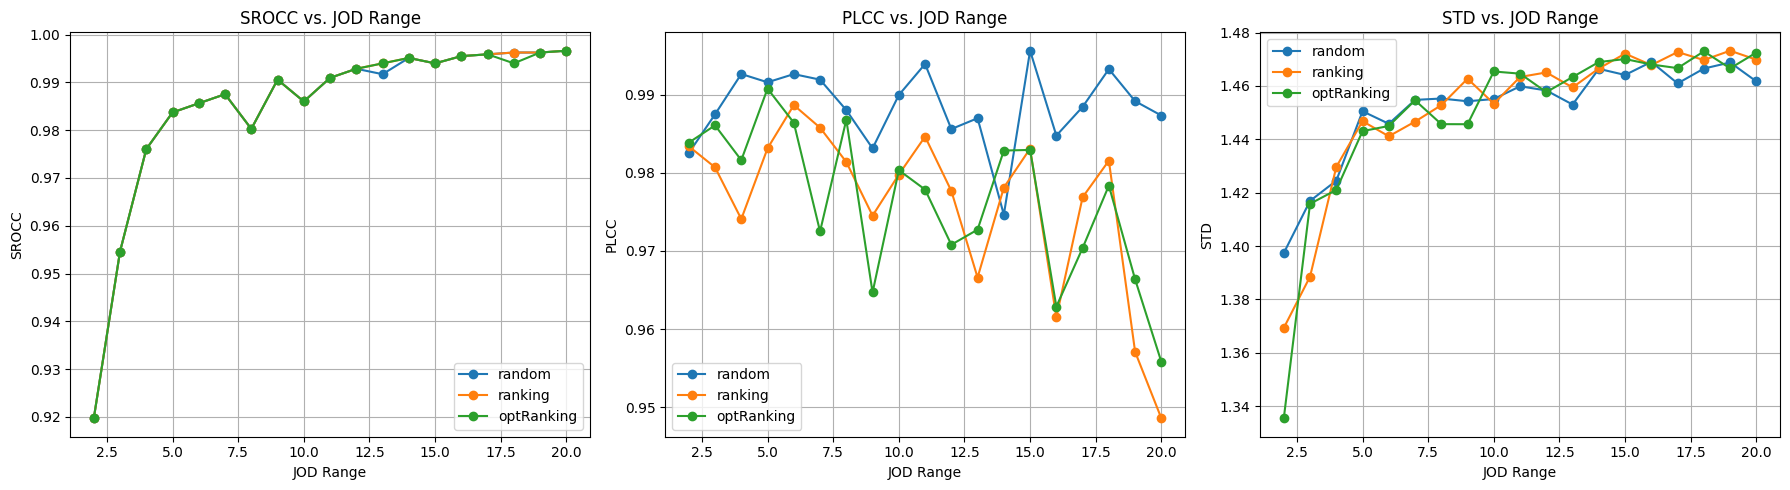

In [56]:
nbImages = 20
nbTrials = 1.5

algorithms = {
    "random": randomSampling,
    "ranking": rankingBasedSampling,
    "optRanking": optRankingBasedSampling,
}

jod_range_list = range(2,21)

results = {
    algo_name: {
        "jod_range": [],
        "PLCC": [],
        "SROCC": [],
        "STD": []
    }
    for algo_name in algorithms
}

for jodRange in jod_range_list:

  groundTruthScores = generateGroundTruthScores(jodRange, nbImages)

  for algo_name, algo_func in algorithms.items():

    avgJodScoreEvolution, avgStdScoreEvolution, duration = monteCarloPwcSim(
        groundTruthScores=groundTruthScores,
        nbTrials=nbTrials,
        observerSimulator=pwcObserverSimulator,
        samplingAlgorithm=algo_func,
        nbSimulations=5
    )

    finalJodScores = avgJodScoreEvolution[-1]

    plcc, srocc, std_err = compute_metrics(finalJodScores, groundTruthScores)

    results[algo_name]["jod_range"].append(jodRange)
    results[algo_name]["PLCC"].append(plcc)
    results[algo_name]["SROCC"].append(srocc)
    results[algo_name]["STD"].append(std_err)

# Plot results
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# SROCC
for algo_name in results:
  axs[0].plot(results[algo_name]["jod_range"],
              results[algo_name]["SROCC"],
              label=algo_name, marker='o')
axs[0].set_title("SROCC vs. JOD Range")
axs[0].set_xlabel("JOD Range")
axs[0].set_ylabel("SROCC")
axs[0].legend()
axs[0].grid(True)

# PLCC
for algo_name in results:
  axs[1].plot(results[algo_name]["jod_range"],
              results[algo_name]["PLCC"],
              label=algo_name, marker='o')
axs[1].set_title("PLCC vs. JOD Range")
axs[1].set_xlabel("JOD Range")
axs[1].set_ylabel("PLCC")
axs[1].legend()
axs[1].grid(True)

# STD
for algo_name in results:
  axs[2].plot(results[algo_name]["jod_range"],
              results[algo_name]["STD"],
              label=algo_name, marker='o')
axs[2].set_title("STD vs. JOD Range")
axs[2].set_xlabel("JOD Range")
axs[2].set_ylabel("STD")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

With nbSimulations=5, we see that SROCC quickly stabilizes above 0.95 for all algorithms and approaches 1.0 at higher JOD ranges, with optRanking showing the fastest climb.

In the PLCC plot, all algorithms again hover around 0.96–0.99 across the JOD range, yet random slightly outperforms the others in some intervals, while ranking and optRanking sometimes dip lower.

The STD plot shows a consistent rise with increasing JOD range for all three, but optRanking maintains the lowest std, indicating that it is better than random or simple ranking strategies.

> A17:

> ### Q18: What are the conclusions you can make from this experiment? What approach performs better and in what situtations?

> #### A18:


Overall, optRanking delivers strong correlations (SROCC, PLCC) and the lowest std, meaning it gives accurate and stable results.

Random can still achieve a good correlation but tends to have higher variance, and ranking falls somewhere in the middle.


With fewer comparisons, optRanking performs better at providing consistent outcomes, while random and ranking-based methods tend to show more variation.